<a href="https://colab.research.google.com/github/Prashkov1ch/python-ai-Prashkovich-Anna/blob/main/%D0%9A%D0%BE%D0%BF%D0%B8%D1%8F_Lab06_Economists_Student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторная работа 6 (экономисты): базовые ML-задачи в scikit-learn

В этой работе вы выполняете **четыре** задания:

1) **Сбор датасета** из 10 Excel-файлов компаний.  
2) **Классификация** (train/test split, sklearn).  
3) **Регрессия** (sklearn).  
4) **Кластеризация** (sklearn).

## Важное предупреждение
- Датасет **маленький** (≈10 компаний) и составлен из агрегированных финансовых показателей.  
- Поэтому метрики моделей (особенно регрессии) могут быть **нестабильными и «не ок»**: высокий разброс, слабая обобщаемость, возможная коллинеарность признаков.  
- Цель лабораторной — **техника построения пайплайна**, а не достижение качества.

**Данные:** используйте предоставленные файлы `.xlsx` (не редактировать).

In [8]:
import re
from openpyxl import load_workbook
import numpy as np
import os
from google.colab import drive

# 1. Монтируем диск (если уже смонтирован, просто игнорируем ошибку)
try:
    drive.mount('/content/drive')
except:
    pass

PATH = '/content/drive/MyDrive/цифровая кафедра/'
os.chdir(PATH)

FILES = ['Копия 1 Атомэнергопром.xlsx', 'Копия 2 Аэрофлот.xlsx', 'Копия 3 Газпром_петрозаводск.xlsx',
         'Копия 4 Лукойл.xlsx', 'Копия 5 Роснефть.xlsx', 'Копия 6 Самолет.xlsx',
         'Копия 7 Славмо.xlsx', 'Копия 8 Строительная_компания_Век.xlsx',
         'Копия 9 ТГК_1.xlsx', 'Копия 10 ТНС_ЭНЭРГО_Карелия.xlsx']

# ML импорты
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

def load_org_name(xlsx_name: str) -> str:
    wb = load_workbook(xlsx_name, data_only=True)
    ws = wb["Сведения об организации"]
    return str(ws.cell(row=6, column=13).value)

def parse_financial(xlsx_name: str):
    wb = load_workbook(xlsx_name, data_only=True)
    ws = wb["Отчет о финансовых результатах"]
    res = {}
    for r in range(6, 300):
        code = ws.cell(r, 16).value
        if code is None:
            continue
        code = str(code).strip()
        if not re.fullmatch(r"\d{4}", code):
            continue
        v23 = ws.cell(r, 21).value
        v22 = ws.cell(r, 27).value
        res[code] = {2022: v22, 2023: v23}
    return res

def parse_balance(xlsx_name: str):
    wb = load_workbook(xlsx_name, data_only=True)
    ws = wb["Бухгалтерский баланс"]
    res = {}
    for r in range(6, 500):
        code = ws.cell(r, 14).value
        if code is None:
            continue
        code = str(code).strip()
        if not re.fullmatch(r"\d{4}", code):
            continue
        v23 = ws.cell(r, 17).value
        v22 = ws.cell(r, 23).value
        res[code] = {2022: v22, 2023: v23}
    return res

# ИСПРАВЛЕНО: добавлена очистка пробелов перед конвертацией
def safe_float(x):
    if x is None:
        return np.nan
    try:
        # Очищаем пробелы и другие символы форматирования
        if isinstance(x, str):
            x = x.replace(' ', '').replace('\xa0', '')
        return float(x)
    except Exception:
        return np.nan

def build_dataset(files):
    import pandas as pd
    rows = []
    for fn in files:
        name = load_org_name(fn)
        fin = parse_financial(fn)
        bal = parse_balance(fn)

        rev22 = safe_float(fin.get("2110", {}).get(2022))
        rev23 = safe_float(fin.get("2110", {}).get(2023))
        pr22  = safe_float(fin.get("2400", {}).get(2022))
        pr23  = safe_float(fin.get("2400", {}).get(2023))

        a22   = safe_float(bal.get("1600", {}).get(2022))
        a23   = safe_float(bal.get("1600", {}).get(2023))
        e22   = safe_float(bal.get("1300", {}).get(2022))
        e23   = safe_float(bal.get("1300", {}).get(2023))

        rows.append({
            "company": name,
            "rev_2022": rev22,
            "rev_2023": rev23,
            "profit_2022": pr22,
            "profit_2023": pr23,
            "assets_2022": a22,
            "assets_2023": a23,
            "equity_2022": e22,
            "equity_2023": e23,
        })
    df = pd.DataFrame(rows)

    df["rev_growth_abs"] = df["rev_2023"] - df["rev_2022"]
    df["profit_growth_abs"] = df["profit_2023"] - df["profit_2022"]

    df["margin_2022"] = df["profit_2022"] / df["rev_2022"]
    df["margin_2023"] = df["profit_2023"] / df["rev_2023"]
    df.loc[df["rev_2022"] == 0, "margin_2022"] = np.nan
    df.loc[df["rev_2023"] == 0, "margin_2023"] = np.nan

    df["equity_ratio_2022"] = df["equity_2022"] / df["assets_2022"]
    df["equity_ratio_2023"] = df["equity_2023"] / df["assets_2023"]
    df.loc[df["assets_2022"] == 0, "equity_ratio_2022"] = np.nan
    df.loc[df["assets_2023"] == 0, "equity_ratio_2023"] = np.nan

    df["target_profit_pos_2023"] = (df["profit_2023"] > 0).astype(int)
    return df

print("Готово: импорты и функции. Файлов:", len(FILES))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Готово: импорты и функции. Файлов: 10


### Задание 1
Соберите датасет из файлов `FILES`:
- одна строка = одна компания,
- признаки: выручка/прибыль/активы/капитал за 2022–2023,
- добавьте производные признаки (рост, маржа, доля капитала),
- сохраните датасет в `economists_ml_dataset.csv`.

Покажите `df.shape` и первые 5 строк.

In [9]:
import pandas as pd

# Собираем датасет
df = build_dataset(FILES)

# Сохраняем в CSV
df.to_csv('economists_ml_dataset.csv', index=False, encoding='utf-8-sig')

# Показываем информацию
print("📊 Датасет собран и сохранён!")
print(f"\nРазмер: {df.shape}")
print(f"\nПервые 5 строк:")
display(df.head())

print(f"\nПропуски в данных:")
print(df.isnull().sum())

/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


📊 Датасет собран и сохранён!

Размер: (10, 16)

Первые 5 строк:


,company,rev_2022,rev_2023,profit_2022,profit_2023,assets_2022,assets_2023,equity_2022,equity_2023,rev_growth_abs,profit_growth_abs,margin_2022,margin_2023,equity_ratio_2022,equity_ratio_2023,target_profit_pos_2023
0,"АКЦИОНЕРНОЕ ОБЩЕСТВО ""АТОМНЫЙ ЭНЕРГОПРОМЫШЛЕНН...",1.851540e+06,1.066798e+07,NaN,91493932.0,2.222861e+09,2.275888e+09,1.464189e+09,1.516195e+09,8816438.0,NaN,NaN,8.576502,0.658696,0.666200,1
1,"ПУБЛИЧНОЕ АКЦИОНЕРНОЕ ОБЩЕСТВО ""АЭРОФЛОТ-РОССИ...",3.327478e+08,4.975113e+08,NaN,NaN,7.847067e+08,9.342681e+08,NaN,NaN,164763502.0,NaN,NaN,NaN,NaN,NaN,0
2,"АКЦИОНЕРНОЕ ОБЩЕСТВО ""ГАЗПРОМ ГАЗОРАСПРЕДЕЛЕН...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
3,"ПУБЛИЧНОЕ АКЦИОНЕРНОЕ ОБЩЕСТВО ""НЕФТЯНАЯ КОМПА...",2.874037e+09,2.753475e+09,790120077.0,655289456.0,2.284260e+09,2.710709e+09,1.265167e+09,1.308113e+09,-120562261.0,-134830621.0,0.274916,0.237986,0.553863,0.482572,1
4,"АКЦИОНЕРНОЕ ОБЩЕСТВО ""ГАЗПРОМ ГАЗОРАСПРЕДЕЛЕН...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0



Пропуски в данных:
company                   0
rev_2022                  3
rev_2023                  3
profit_2022               6
profit_2023               5
assets_2022               3
assets_2023               3
equity_2022               4
equity_2023               4
rev_growth_abs            3
profit_growth_abs         7
margin_2022               6
margin_2023               5
equity_ratio_2022         4
equity_ratio_2023         4
target_profit_pos_2023    0
dtype: int64


### Задание 2
Разделите данные на тренировочную и тестовую выборки (`train_test_split`).  
**Задача классификации:** предсказать `target_profit_pos_2023` (прибыль 2023 > 0).

Рекомендация:
- признаки: все числовые столбцы, кроме целевой,
- `Pipeline`: `SimpleImputer(median)` → `StandardScaler` → `LogisticRegression`,
- метрики: `accuracy`, `confusion_matrix`, `classification_report`.

Покажите метрики на тестовой выборке.

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 1. Подготовка данных - выбираем только числовые столбцы с данными
feature_cols = [col for col in df.select_dtypes(include=['float64', 'int64']).columns
                if col not in ['target_profit_pos_2023'] and df[col].notna().any()]

print(f"Признаки: {feature_cols}")

X = df[feature_cols]
y = df['target_profit_pos_2023']

# 2. Разделение на train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 3. Создание пайплайна
clf_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(random_state=42, max_iter=1000))
])

# 4. Обучение модели
clf_pipeline.fit(X_train, y_train)

# 5. Предсказание и метрики
y_pred = clf_pipeline.predict(X_test)

print("\n📊 Метрики классификации:")
print("=" * 50)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print(f"\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

Признаки: ['rev_2022', 'rev_2023', 'profit_2022', 'profit_2023', 'assets_2022', 'assets_2023', 'equity_2022', 'equity_2023', 'rev_growth_abs', 'profit_growth_abs', 'margin_2022', 'margin_2023', 'equity_ratio_2022', 'equity_ratio_2023']

📊 Метрики классификации:
Accuracy: 1.000

Confusion Matrix:
[[2 0]
 [0 1]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         1

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



### Задание 3
**Задача регрессии:** предсказать `rev_2023` по остальным числовым признакам.

Рекомендация:
- `Pipeline`: `SimpleImputer(median)` → `StandardScaler` → `Ridge`,
- метрики: MAE, RMSE, R².

Внимание: на таком датасете R² и стабильность модели могут быть плохими — это ожидаемо.

In [13]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 1. Подготовка данных
X_reg = df[feature_cols].copy()
y_reg = df['rev_2023'].copy()

# 2. ИСПРАВЛЕНИЕ: Удаляем строки где целевая переменная содержит NaN
# Создаём маску валидных данных
valid_mask = ~np.isnan(y_reg)
X_reg = X_reg[valid_mask]
y_reg = y_reg[valid_mask]

print(f"Строк после удаления NaN: {len(y_reg)} из {len(df)}")

# 3. Разделение на train/test
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.3, random_state=42
)

# 4. Создание пайплайна
reg_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('regressor', Ridge(alpha=1.0, random_state=42))
])

# 5. Обучение модели
reg_pipeline.fit(X_train_reg, y_train_reg)

# 6. Предсказание и метрики
y_pred_reg = reg_pipeline.predict(X_test_reg)

mae = mean_absolute_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))
r2 = r2_score(y_test_reg, y_pred_reg)

print("\n📊 Метрики регрессии:")
print("=" * 50)
print(f"MAE (средняя абсолютная ошибка): {mae:,.0f} руб.")
print(f"RMSE (корень из MSE): {rmse:,.0f} руб.")
print(f"R² (коэффициент детерминации): {r2:.3f}")

print("\n⚠️ Примечание: на маленьком датасете R² может быть низким")
print("или отрицательным — это ожидаемое поведение.")

Строк после удаления NaN: 7 из 10

📊 Метрики регрессии:
MAE (средняя абсолютная ошибка): 271,622,281 руб.
RMSE (корень из MSE): 406,913,888 руб.
R² (коэффициент детерминации): -2.707

⚠️ Примечание: на маленьком датасете R² может быть низким
или отрицательным — это ожидаемое поведение.


### Задание 4
**Задача кластеризации:** сгруппировать компании по финансовым признакам.

Рекомендация:
- возьмите те же числовые признаки,
- `SimpleImputer` + `StandardScaler`,
- попробуйте `KMeans` для `k=2..4` и выберите k по `silhouette_score`,
- добавьте метку кластера в `df["cluster"]`,
- визуализируйте в 2D через PCA (scatter с подписями компаний).

Покажите выбранный k и список компаний по кластерам.

🔍 Поиск оптимального количества кластеров:
  k=2: silhouette_score = 0.515
  k=3: silhouette_score = 0.474
  k=4: silhouette_score = 0.535

✅ Выбрано k = 4 (max silhouette = 0.535)


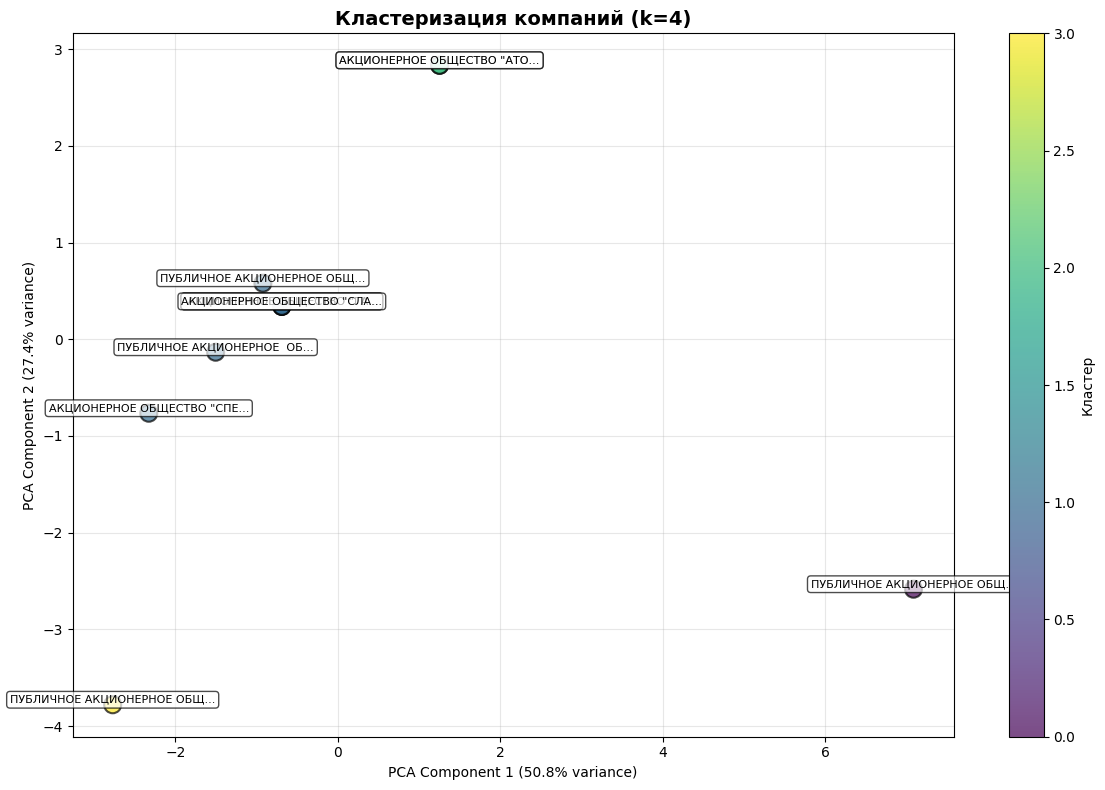


📋 Компании по кластерам:

🔹 Кластер 0 (1 компаний):
     • ПУБЛИЧНОЕ АКЦИОНЕРНОЕ ОБЩЕСТВО "НЕФТЯНАЯ КОМПАНИЯ "ЛУКОЙЛ"

🔹 Кластер 1 (6 компаний):
     • ПУБЛИЧНОЕ АКЦИОНЕРНОЕ ОБЩЕСТВО "АЭРОФЛОТ-РОССИЙСКИЕ АВИАЛИНИИ"
     •  АКЦИОНЕРНОЕ ОБЩЕСТВО "ГАЗПРОМ ГАЗОРАСПРЕДЕЛЕНИЕ ПЕТРОЗАВОДСК"
     •  АКЦИОНЕРНОЕ ОБЩЕСТВО "ГАЗПРОМ ГАЗОРАСПРЕДЕЛЕНИЕ ПЕТРОЗАВОДСК"
     • АКЦИОНЕРНОЕ ОБЩЕСТВО "СЛАВМО"
     • АКЦИОНЕРНОЕ ОБЩЕСТВО "СПЕЦИАЛИЗИРОВАННЫЙ ЗАСТРОЙЩИК "СТРОИТЕЛЬНАЯ КОМПАНИЯ "ВЕК"
     • ПУБЛИЧНОЕ АКЦИОНЕРНОЕ  ОБЩЕСТВО  "ТЕРРИТОРИАЛЬНАЯ  ГЕНЕРИРУЮЩАЯ  КОМПАНИЯ   №1"

🔹 Кластер 2 (2 компаний):
     • АКЦИОНЕРНОЕ ОБЩЕСТВО "АТОМНЫЙ ЭНЕРГОПРОМЫШЛЕННЫЙ КОМПЛЕКС"
     • АКЦИОНЕРНОЕ ОБЩЕСТВО "АТОМНЫЙ ЭНЕРГОПРОМЫШЛЕННЫЙ КОМПЛЕКС"

🔹 Кластер 3 (1 компаний):
     • ПУБЛИЧНОЕ АКЦИОНЕРНОЕ ОБЩЕСТВО "ГРУППА КОМПАНИЙ "САМОЛЕТ"

📊 Средние значения признаков по кластерам:


,rev_2022,rev_2023,profit_2022,profit_2023,assets_2022,assets_2023,equity_2022,equity_2023,rev_growth_abs,profit_growth_abs,margin_2022,margin_2023,equity_ratio_2022,equity_ratio_2023
cluster,,,,,,,,,,,,,,
0,2.874037e+09,2.753475e+09,790120077.0,655289456.0,2.284260e+09,2.710709e+09,1.265167e+09,1.308113e+09,-1.205623e+08,-134830621.0,0.27,0.24,0.55,0.48
1,1.440719e+08,2.001760e+08,3859605.0,870349.0,3.269152e+08,3.791571e+08,7.354343e+07,7.358108e+07,5.610409e+07,279063.0,0.50,0.66,0.71,0.75
2,1.851540e+06,1.066798e+07,NaN,91493932.0,2.222861e+09,2.275888e+09,1.464189e+09,1.516195e+09,8.816438e+06,NaN,NaN,8.58,0.66,0.67
3,3.209771e+06,6.841987e+06,7475995.0,7667268.0,1.115640e+08,1.903084e+08,9.413406e+06,1.747355e+07,3.632216e+06,191273.0,2.33,1.12,0.08,0.09


In [14]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# 1. Подготовка данных - те же числовые признаки, что в заданиях 2-3
feature_cols = [col for col in df.select_dtypes(include=['float64', 'int64']).columns
                if col not in ['target_profit_pos_2023', 'cluster']]

X_cluster = df[feature_cols].copy()

# 2. Предобработка: импутер + скалер
preprocess = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

X_scaled = preprocess.fit_transform(X_cluster)

# 3. Поиск оптимального k по silhouette score (k=2..4)
print("🔍 Поиск оптимального количества кластеров:")
print("=" * 60)

silhouette_scores = {}
for k in range(2, 5):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores[k] = score
    print(f"  k={k}: silhouette_score = {score:.3f}")

# Выбираем k с максимальным score
best_k = max(silhouette_scores, key=silhouette_scores.get)
print(f"\n✅ Выбрано k = {best_k} (max silhouette = {silhouette_scores[best_k]:.3f})")

# 4. Финальная кластеризация с выбранным k
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df['cluster'] = kmeans_final.fit_predict(X_scaled)

# 5. Визуализация через PCA (2D scatter с подписями компаний)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                      c=df['cluster'], cmap='viridis',
                      s=150, alpha=0.7, edgecolors='black', linewidth=1.5)

# Подписываем компании
for i, company in enumerate(df['company']):
    plt.annotate(company[:25] + '...',
                 (X_pca[i, 0], X_pca[i, 1]),
                 fontsize=8, ha='center', va='bottom',
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

plt.xlabel(f'PCA Component 1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PCA Component 2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.title(f'Кластеризация компаний (k={best_k})', fontsize=14, fontweight='bold')
plt.colorbar(scatter, label='Кластер')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 6. Вывод компаний по кластерам
print("\n" + "=" * 60)
print("📋 Компании по кластерам:")
print("=" * 60)
for cluster_id in range(best_k):
    companies = df[df['cluster'] == cluster_id]['company'].tolist()
    print(f"\n🔹 Кластер {cluster_id} ({len(companies)} компаний):")
    for company in companies:
        print(f"     • {company}")

# 7. Статистика по кластерам (средние значения признаков)
print("\n" + "=" * 60)
print("📊 Средние значения признаков по кластерам:")
print("=" * 60)
cluster_stats = df.groupby('cluster')[feature_cols].mean()
display(cluster_stats.round(2))